In [1]:
# Import TensorFlow
# Why? TensorFlow is used to build and train our deep learning model.
import tensorflow as tf

# Import Keras layers and model utilities
# Why? These help us create the transfer learning model.
from tensorflow.keras import layers, Model

# Import ResNet50
# Why? ResNet50 is a pretrained deep learning model that can extract useful image features.
from tensorflow.keras.applications import ResNet50

# Import NumPy
# Why? NumPy is useful for numerical operations during model development.
import numpy as np

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.21.0
Libraries imported successfully!


In [2]:
# Set the path of our processed dataset
# Why? We need to tell TensorFlow where our train, validation, and test images are stored.
dataset_path = r"C:\Users\Gopal\Automated_Road_Damage_Classification\dataset"

# Define the image size expected by ResNet50
# Why? ResNet50 uses 224 x 224 pixel images.
image_size = (224, 224)

# Define the batch size
# Why? Images are processed in small groups to use memory efficiently.
batch_size = 32

# Define the class names
# Why? These are the three types of road damage in our project.
class_names = ["pothole", "crack", "manhole"]

# Load the training dataset
# Why? This dataset is used to train the ResNet50 model.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path + r"\train",
    image_size=image_size,
    batch_size=batch_size,
    class_names=class_names,
    shuffle=True,
    seed=42
)

# Load the validation dataset
# Why? Validation data helps us monitor the model during training.
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path + r"\validation",
    image_size=image_size,
    batch_size=batch_size,
    class_names=class_names,
    shuffle=False
)

# Load the test dataset
# Why? Test data is kept separate and used only for final evaluation.
test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path + r"\test",
    image_size=image_size,
    batch_size=batch_size,
    class_names=class_names,
    shuffle=False
)

print("Class names:", class_names)
print("Datasets loaded successfully!")

Found 702 files belonging to 3 classes.
Found 173 files belonging to 3 classes.
Found 151 files belonging to 3 classes.
Class names: ['pothole', 'crack', 'manhole']
Datasets loaded successfully!


In [3]:
# Load the ResNet50 model with pretrained ImageNet weights
# Why? Instead of learning all image features from zero,
# we use features already learned from a large image dataset.

base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the ResNet50 layers initially
# Why? We first use ResNet50 as a feature extractor.
# This prevents the pretrained weights from changing during initial training.
base_model.trainable = False

# Display the number of layers in the ResNet50 model
print("Total ResNet50 layers:", len(base_model.layers))

print("ResNet50 loaded successfully!")
print("Pretrained layers are frozen.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step
Total ResNet50 layers: 175
ResNet50 loaded successfully!
Pretrained layers are frozen.


In [4]:
# Create the input layer
# Why? Our model receives road-damage images of size 224 x 224 with 3 color channels.
inputs = layers.Input(shape=(224, 224, 3))

# Apply data augmentation only during training
# Why? Augmentation creates slightly different versions of training images
# and helps the model generalize better to new images.
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.1)(x)
x = layers.RandomBrightness(factor=0.2)(x)
x = layers.RandomZoom(0.1)(x)

# Preprocess the images for ResNet50
# Why? ResNet50 pretrained on ImageNet expects its specific input preprocessing.
x = tf.keras.applications.resnet50.preprocess_input(x)

# Pass the images through the frozen pretrained ResNet50
# training=False keeps Batch Normalization layers in inference mode
# while we are initially training only the new classification layers.
x = base_model(x, training=False)

# Convert the feature maps into a single feature vector
# Why? This reduces the number of parameters compared with Flatten()
# and helps the model focus on the most important extracted features.
x = layers.GlobalAveragePooling2D()(x)

# Add a fully connected layer for learning our road-damage patterns
x = layers.Dense(128, activation="relu")(x)

# Dropout helps reduce overfitting
x = layers.Dropout(0.3)(x)

# Final classification layer
# Why? We have 3 road-damage classes.
outputs = layers.Dense(3, activation="softmax")(x)

# Create the complete ResNet50 classification model
resnet_model = Model(inputs, outputs)

# Display the model architecture
resnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ random_flip (RandomFlip)      │ (None, 224, 224, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ random_rotation               │ (None, 224, 224, 3)       │               0 │ random_flip[0][0]          │
│ (RandomRotation)              │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ random_brightness             │ (None, 224, 224, 3)       │               0 │ random_rotation[0][0]      │
│ (RandomBrightness)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ random_zoom (RandomZoom)      │ (None, 224, 224, 3)       │               0 │ random_brightness[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 224, 224)          │               0 │ random_zoom[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 224, 224)          │               0 │ random_zoom[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 224, 224)          │               0 │ random_zoom[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack (Stack)                 │ (None, 224, 224, 3)       │               0 │ get_item[0][0],            │
│                               │                           │                 │ get_item_1[0][0],          │
│                               │                           │                 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 224, 224, 3)       │               0 │ stack[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 7, 7, 2048)        │      23,587,712 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 2048)              │               0 │ resnet50[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         262,272 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 3)                 │             38

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [5]:
# Compile the ResNet50 model
# Why? Compilation defines how the model learns and how we measure its performance.

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 model compiled successfully!")

ResNet50 model compiled successfully!


In [6]:
# Define class weights for the three road-damage classes
# Why? The dataset is imbalanced, especially for the manhole class.
# Higher weight gives more importance to the underrepresented class.

class_weights = {
    0: 1.00,   # Pothole
    1: 0.58,   # Crack
    2: 3.49    # Manhole
}

# Display the class weights
print("Class weights:")
print("Pothole :", class_weights[0])
print("Crack   :", class_weights[1])
print("Manhole :", class_weights[2])

Class weights:
Pothole : 1.0
Crack   : 0.58
Manhole : 3.49


In [7]:
# Import callbacks
# Why? Callbacks help us control training and automatically save the best model.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training when validation loss stops improving
# Why? This helps prevent overfitting and unnecessary training.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Save the model whenever validation loss improves
# Why? We want to keep the best-performing ResNet50 model.
model_checkpoint = ModelCheckpoint(
    "resnet50_feature_extraction_best.keras",
    monitor="val_loss",
    save_best_only=True
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [8]:
# Train the ResNet50 model
# Why? We first train only the new classification layers
# while keeping the pretrained ResNet50 feature extractor frozen.

history_resnet = resnet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/20


C:\Users\Gopal\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


22/22 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.4772 - loss: 1.2020 - val_accuracy: 0.5838 - val_loss: 0.8774
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6239 - loss: 0.8347 - val_accuracy: 0.7514 - val_loss: 0.6619
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7208 - loss: 0.7173 - val_accuracy: 0.7399 - val_loss: 0.6901
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 680s 32s/step - accuracy: 0.6980 - loss: 0.6815 - val_accuracy: 0.7630 - val_loss: 0.6108
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7764 - loss: 0.5916 - val_accuracy: 0.7977 - val_loss: 0.5571
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 229s 11s/step - accuracy: 0.7821 - loss: 0.6039 - val_accuracy: 0.7688 - val_loss: 0.5998
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.7664 - loss: 0.6005 - val_accuracy: 0.8035 - val_loss: 0.5285
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7906 - loss: 0.5400 - val_accuracy: 0.7919 - val_loss: 0.5228

In [9]:
# Evaluate ResNet50 on the unseen test dataset
# Why? Test data gives us the final performance on images
# that were not used during training or validation.

resnet_test_loss, resnet_test_accuracy = resnet_model.evaluate(
    test_dataset
)

print("ResNet50 Test Loss:", resnet_test_loss)
print("ResNet50 Test Accuracy:", resnet_test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8675 - loss: 0.3617
ResNet50 Test Loss: 0.36166590452194214
ResNet50 Test Accuracy: 0.8675496578216553


“The baseline CNN learns image features from the training dataset from scratch. ResNet50 uses pretrained features learned from ImageNet, so it can identify useful patterns such as edges, textures, shapes and complex visual features more effectively. Therefore, ResNet50 achieved higher test accuracy.”

In [11]:
# Import classification_report
# Why? It calculates precision, recall and F1-score for each damage class.
from sklearn.metrics import classification_report

# Display the ResNet50 classification report
print("ResNet50 Classification Report:")

print(
    classification_report(
        y_true_resnet,
        y_pred_resnet,
        target_names=class_names,
        digits=4
    )
)

ResNet50 Classification Report:
              precision    recall  f1-score   support

     pothole     0.8644    0.8226    0.8430        62
       crack     0.9054    0.9306    0.9178        72
     manhole     0.7222    0.7647    0.7429        17

    accuracy                         0.8675       151
   macro avg     0.8307    0.8393    0.8345       151
weighted avg     0.8679    0.8675    0.8674       151



“Our baseline CNN achieved 58.94% test accuracy. After using ResNet50 with pretrained ImageNet features, the test accuracy increased to 86.75%. The macro F1-score also increased from 52.20% to 83.45%, showing improved performance across the three damage classes.”

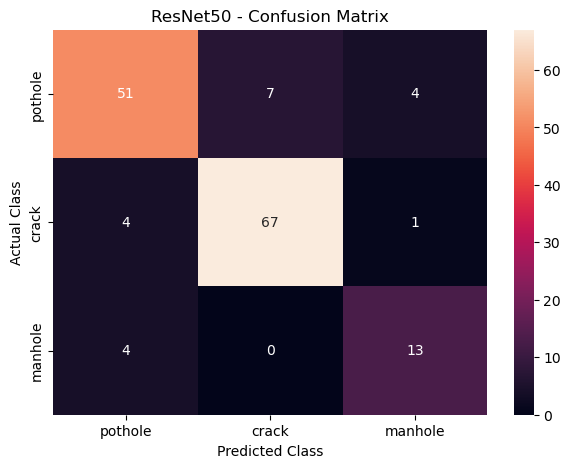

In [16]:
# Import libraries required to display the confusion matrix
# Why? Matplotlib creates the plot and Seaborn makes the matrix easier to read.
import matplotlib.pyplot as plt
import seaborn as sns

# Display the ResNet50 confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("ResNet50 - Confusion Matrix")

plt.show()

“The ResNet50 confusion matrix shows that most samples are correctly classified along the diagonal. Out of 62 pothole images, 51 were correctly identified; out of 72 crack images, 67 were correctly identified; and out of 17 manhole images, 13 were correctly identified. This demonstrates that transfer learning significantly improved classification compared with the baseline CNN.”

In [17]:
# Enable fine-tuning for the ResNet50 model
# Why?
# The first training stage used ResNet50 only as a frozen feature extractor.
# Now we allow some deeper layers to learn road-damage-specific features.

base_model.trainable = True

# Freeze the early ResNet50 layers
# Why?
# Early layers learn general features such as edges and textures.
# We keep them frozen and fine-tune only the deeper layers.
fine_tune_from = 145

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

# Keep Batch Normalization layers frozen
# Why?
# This makes fine-tuning more stable, especially with our relatively small dataset.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Count trainable and non-trainable parameters
trainable_params = sum(
    np.prod(layer.shape)
    for layer in base_model.trainable_weights
)

non_trainable_params = sum(
    np.prod(layer.shape)
    for layer in base_model.non_trainable_weights
)

print("Fine-tuning enabled!")
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Fine-tuning enabled!
Trainable parameters: 14428672
Non-trainable parameters: 9159040


In [18]:
# Recompile the model with a very small learning rate
# Why?
# Fine-tuning changes pretrained weights, so we use small updates
# to avoid destroying the useful features learned from ImageNet.

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 fine-tuning model compiled successfully!")

ResNet50 fine-tuning model compiled successfully!


In [19]:
# Create separate callbacks for the fine-tuning stage
# Why? We already have a good feature-extraction model.
# A separate file prevents us from overwriting that model.

fine_tune_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

fine_tune_checkpoint = ModelCheckpoint(
    "resnet50_finetuned_best.keras",
    monitor="val_loss",
    save_best_only=True
)

print("Fine-tuning callbacks created successfully!")

Fine-tuning callbacks created successfully!


In [20]:
# Fine-tune the ResNet50 model
# Why?
# We now allow the deeper pretrained layers to adapt specifically
# to our road-damage images.

fine_tune_history = resnet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    class_weight=class_weights,
    callbacks=[
        fine_tune_early_stopping,
        fine_tune_checkpoint
    ]
)

Epoch 1/15


C:\Users\Gopal\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


22/22 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.8248 - loss: 0.4543 - val_accuracy: 0.8150 - val_loss: 0.4968
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8376 - loss: 0.4105 - val_accuracy: 0.8439 - val_loss: 0.4714
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.8476 - loss: 0.4010 - val_accuracy: 0.8266 - val_loss: 0.4580
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.8447 - loss: 0.3503 - val_accuracy: 0.8266 - val_loss: 0.4637
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.8789 - loss: 0.3318 - val_accuracy: 0.8208 - val_loss: 0.4929
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.8661 - loss: 0.3098 - val_accuracy: 0.8497 - val_loss: 0.4790
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.8661 - loss: 0.3259 - val_accuracy: 0.8382 - val_loss: 0.4855
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.8746 - loss: 0.3191 - val_accuracy: 0.7977 - val_loss: 0.5196


In [21]:
# Evaluate the fine-tuned ResNet50 on the unseen test dataset
# Why? The test dataset gives us the final performance of the fine-tuned model.

fine_tune_test_loss, fine_tune_test_accuracy = resnet_model.evaluate(
    test_dataset
)

print("Fine-Tuned ResNet50 Test Loss:", fine_tune_test_loss)
print("Fine-Tuned ResNet50 Test Accuracy:", fine_tune_test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.8675 - loss: 0.3509
Fine-Tuned ResNet50 Test Loss: 0.35086843371391296
Fine-Tuned ResNet50 Test Accuracy: 0.8675496578216553


In [22]:
# Generate predictions from the fine-tuned ResNet50 model
# Why? We need fresh predictions after fine-tuning
# to calculate the final Precision, Recall and F1-score.

y_true_finetuned = []
y_pred_finetuned = []

for images, labels in test_dataset:
    predictions = resnet_model.predict(images, verbose=0)

    # Select the class with the highest probability
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_finetuned.extend(labels.numpy())
    y_pred_finetuned.extend(predicted_classes)

# Convert lists to NumPy arrays
y_true_finetuned = np.array(y_true_finetuned)
y_pred_finetuned = np.array(y_pred_finetuned)

# Display the final classification report
print("Fine-Tuned ResNet50 Classification Report:")

print(
    classification_report(
        y_true_finetuned,
        y_pred_finetuned,
        target_names=class_names,
        digits=4
    )
)

Fine-Tuned ResNet50 Classification Report:
              precision    recall  f1-score   support

     pothole     0.9091    0.8065    0.8547        62
       crack     0.9178    0.9306    0.9241        72
     manhole     0.6087    0.8235    0.7000        17

    accuracy                         0.8675       151
   macro avg     0.8119    0.8535    0.8263       151
weighted avg     0.8794    0.8675    0.8704       151



“After fine-tuning the deeper layers of ResNet50 with a low learning rate, the test accuracy remained at 86.75%. However, the macro F1-score changed from 83.45% to 82.63%, while the weighted F1-score increased from 86.74% to 87.04%. Fine-tuning therefore changed the class-level prediction behavior, particularly improving manhole recall, but it did not increase overall test accuracy.”

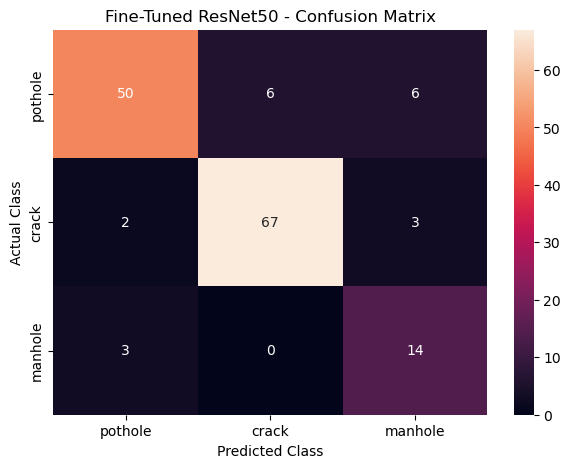

In [23]:
# Create the confusion matrix for the fine-tuned ResNet50
# Why? This shows exactly which road-damage classes
# are being correctly and incorrectly classified.

cm_finetuned = confusion_matrix(
    y_true_finetuned,
    y_pred_finetuned
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_finetuned,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Fine-Tuned ResNet50 - Confusion Matrix")

plt.show()

In [24]:
# Find the last convolutional layer inside ResNet50
# Why?
# Grad-CAM uses the feature maps from the last convolutional layer
# to show which image regions influenced the prediction.

last_conv_layer = base_model.get_layer("conv5_block3_out")

print("Last convolutional layer:", last_conv_layer.name)
print("Output shape:", last_conv_layer.output.shape)

Last convolutional layer: conv5_block3_out
Output shape: (None, 7, 7, 2048)


In [26]:
# Import Matplotlib
# Why? It is used later to display the Grad-CAM heatmap.
import matplotlib.pyplot as plt


def make_gradcam_heatmap(img_array, model, last_conv_layer):
    """
    Generate a Grad-CAM heatmap for one image.

    img_array:
        Image with shape (1, 224, 224, 3)

    model:
        Our trained Fine-Tuned ResNet50 model

    last_conv_layer:
        Last convolutional layer used for Grad-CAM
    """

    # Create a model that returns:
    # 1. Feature maps from the last convolutional layer
    # 2. Final prediction probabilities
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            last_conv_layer.output,
            model.output
        ]
    )

    # Calculate the gradients for the predicted class
    # Why? Gradients tell us which features are important for the prediction.
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        # Find the predicted class
        predicted_class = tf.argmax(predictions[0])

        # Get the probability of the predicted class
        class_probability = predictions[:, predicted_class]

    # Calculate gradients with respect to the convolutional feature maps
    grads = tape.gradient(
        class_probability,
        conv_outputs
    )

    # Calculate the average importance of each feature map
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove the batch dimension
    conv_outputs = conv_outputs[0]

    # Combine feature maps using their importance
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    # Remove the extra dimension
    heatmap = tf.squeeze(heatmap)

    # Keep only positive values
    # Why? Positive values represent regions supporting the prediction.
    heatmap = tf.maximum(heatmap, 0)

    # Normalize values between 0 and 1
    heatmap = heatmap / (
        tf.reduce_max(heatmap) + tf.keras.backend.epsilon()
    )

    return (
        heatmap.numpy(),
        int(predicted_class),
        float(class_probability[0])
    )


print("Grad-CAM function created successfully!")

Grad-CAM function created successfully!


In [27]:
# Import os
# Why? We use it to find image files inside our test dataset folder.
import os

# Find all test images from the three damage-class folders
# Why? We need one real unseen test image for Grad-CAM.
test_image_paths = []

for class_name in class_names:
    class_folder = os.path.join(
        dataset_path,
        "test",
        class_name
    )

    for file_name in os.listdir(class_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            test_image_paths.append(
                os.path.join(class_folder, file_name)
            )

# Select the first test image
sample_image_path = test_image_paths[0]

print("Selected test image:")
print(sample_image_path)

Selected test image:
C:\Users\Gopal\Automated_Road_Damage_Classification\dataset\test\pothole\20250219_164754_ann_35.jpg


In [28]:
# Load the selected test image
# Why? We need to convert the image into a format that our ResNet50 model can process.

img = tf.keras.utils.load_img(
    sample_image_path,
    target_size=(224, 224)
)

# Convert the image into a NumPy array
# Why? TensorFlow models work with numerical arrays rather than image files.
img_array = tf.keras.utils.img_to_array(img)

# Add a batch dimension
# Why? The model expects input in the format:
# (batch_size, height, width, channels)
img_array = np.expand_dims(img_array, axis=0)

# Apply the same preprocessing used by ResNet50
# Why? The image must be prepared in the same way as during model training.
img_array = tf.keras.applications.resnet50.preprocess_input(
    img_array
)

print("Image loaded successfully!")
print("Image shape:", img_array.shape)

Image loaded successfully!
Image shape: (1, 224, 224, 3)


In [33]:
# Create a Grad-CAM function for our nested ResNet50 model
# Why?
# Keras 3 can have connection issues when we directly connect
# an inner layer of a nested model to the outer model.
# So here we calculate the ResNet50 feature maps directly
# and then pass them through our classification layers.

def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer):

    # Create a model that returns the selected convolutional layer
    # and the final ResNet50 feature output.
    resnet_grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            last_conv_layer.output,
            base_model.output
        ]
    )

    # Calculate the ResNet50 input
    # Our img_array is already in ResNet50 preprocessed format.
    with tf.GradientTape() as tape:

        # Get convolutional feature maps and final ResNet50 features
        conv_outputs, features = resnet_grad_model(
            img_array,
            training=False
        )

        # Apply the same classification head used by our model
        x = model.get_layer("global_average_pooling2d")(features)
        x = model.get_layer("dense")(x)
        x = model.get_layer("dropout")(x, training=False)
        predictions = model.get_layer("dense_1")(x)

        # Find the predicted class
        predicted_class = tf.argmax(predictions[0])

        # Get the probability of the predicted class
        class_probability = predictions[:, predicted_class]

    # Calculate gradients of the predicted class
    # with respect to the convolutional feature maps.
    grads = tape.gradient(
        class_probability,
        conv_outputs
    )

    # Calculate the average importance of each feature map
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove the batch dimension
    conv_outputs = conv_outputs[0]

    # Weight the feature maps according to their importance
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    # Remove the extra dimension
    heatmap = tf.squeeze(heatmap)

    # Keep only positive values
    # Why? Positive values show regions supporting the prediction.
    heatmap = tf.maximum(heatmap, 0)

    # Normalize the heatmap between 0 and 1
    heatmap = heatmap / (
        tf.reduce_max(heatmap) + tf.keras.backend.epsilon()
    )

    return (
        heatmap.numpy(),
        int(predicted_class),
        float(class_probability[0])
    )


print("Final Grad-CAM function created successfully!")

Final Grad-CAM function created successfully!


Predicted Class: pothole
Confidence: 72.48 %


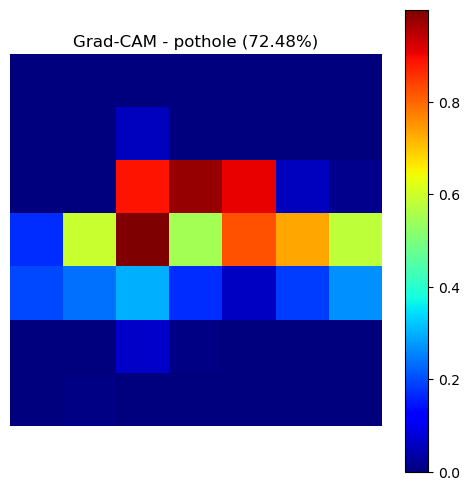

In [34]:
# Generate the Grad-CAM heatmap for our selected test image
# Why? This shows which regions of the image influenced the model's prediction.

heatmap, predicted_class, confidence = make_gradcam_heatmap(
    img_array,
    resnet_model,
    base_model,
    last_conv_layer
)

# Convert the predicted class number into the class name
predicted_label = class_names[predicted_class]

# Display the prediction result
print("Predicted Class:", predicted_label)
print("Confidence:", round(confidence * 100, 2), "%")

# Display the raw Grad-CAM heatmap
# Why? Brighter regions indicate areas that contributed more
# to the model's prediction.
plt.figure(figsize=(6, 6))

plt.imshow(heatmap, cmap="jet")
plt.colorbar()

plt.title(
    f"Grad-CAM - {predicted_label} ({confidence * 100:.2f}%)"
)

plt.axis("off")
plt.show()

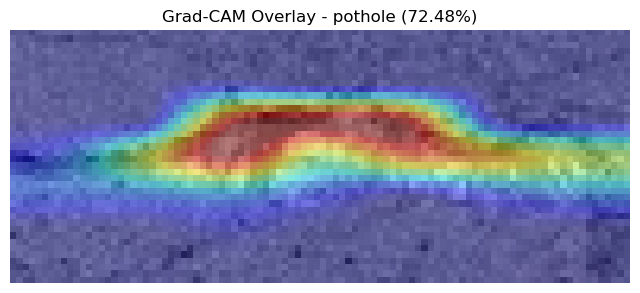

In [35]:
# Import PIL for image processing
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load the original image
original_image = Image.open(sample_image_path).convert("RGB")

# Resize the Grad-CAM heatmap to the original image size
heatmap_resized = Image.fromarray(
    np.uint8(heatmap * 255)
).resize(original_image.size)

# Convert heatmap into a color map
heatmap_array = np.array(heatmap_resized)

# Display the original image
plt.figure(figsize=(8, 8))

# Show original image
plt.imshow(original_image)

# Overlay the Grad-CAM heatmap
plt.imshow(
    heatmap_array,
    cmap="jet",
    alpha=0.45
)

# Add prediction information
plt.title(
    f"Grad-CAM Overlay - {predicted_label} "
    f"({confidence * 100:.2f}%)"
)

plt.axis("off")
plt.show()

“Grad-CAM helps us understand which region of the road image influenced the model's prediction. The red and orange regions indicate areas that contributed more strongly to the pothole prediction.”

In [36]:
# Select one test image from each damage class
# We use these images later to generate Grad-CAM visualizations.

import os

test_path = r"C:\Users\Gopal\Automated_Road_Damage_Classification\dataset\test"

sample_images = {}

for class_name in class_names:
    
    class_folder = os.path.join(test_path, class_name)
    
    # Get image files from the class folder
    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    # Select the first available image
    if image_files:
        sample_images[class_name] = os.path.join(
            class_folder,
            image_files[0]
        )

print("Selected Grad-CAM sample images:\n")

for class_name, image_path in sample_images.items():
    print(class_name, ":", image_path)

Selected Grad-CAM sample images:

pothole : C:\Users\Gopal\Automated_Road_Damage_Classification\dataset\test\pothole\20250219_164754_ann_35.jpg
crack : C:\Users\Gopal\Automated_Road_Damage_Classification\dataset\test\crack\20250219_164754_ann_37.jpg
manhole : C:\Users\Gopal\Automated_Road_Damage_Classification\dataset\test\manhole\20250219_164807_ann_44.jpg


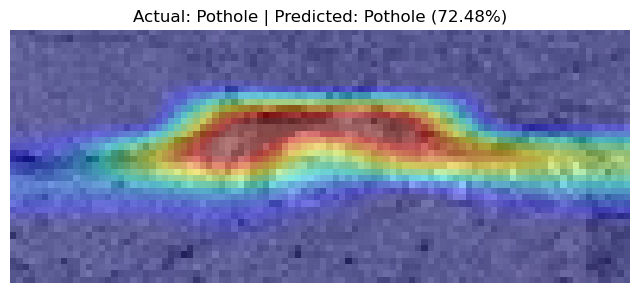

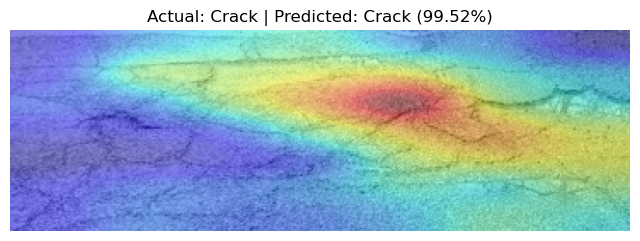

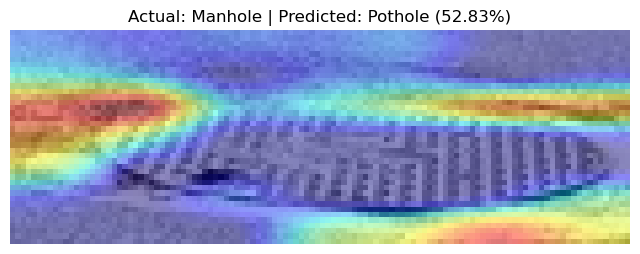

In [37]:
# Generate Grad-CAM overlays for Pothole, Crack, and Manhole
# This helps us visually understand where the model focuses
# when making predictions for each damage type.

for actual_class, image_path in sample_images.items():

    # Load the image and resize it to the model input size
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert image to NumPy array
    img_array = tf.keras.utils.img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Apply ResNet50 preprocessing
    img_array = tf.keras.applications.resnet50.preprocess_input(
        img_array
    )

    # Generate Grad-CAM heatmap
    heatmap, predicted_class, confidence = make_gradcam_heatmap(
        img_array,
        resnet_model,
        base_model,
        last_conv_layer
    )

    # Convert predicted class number into class name
    predicted_label = class_names[predicted_class]

    # Load original image for displaying the overlay
    original_image = Image.open(image_path).convert("RGB")

    # Resize heatmap to match original image size
    heatmap_resized = Image.fromarray(
        np.uint8(heatmap * 255)
    ).resize(original_image.size)

    heatmap_array = np.array(heatmap_resized)

    # Create Grad-CAM overlay
    plt.figure(figsize=(8, 5))

    # Display original image
    plt.imshow(original_image)

    # Overlay Grad-CAM heatmap
    plt.imshow(
        heatmap_array,
        cmap="jet",
        alpha=0.45
    )

    # Display actual and predicted class
    plt.title(
        f"Actual: {actual_class.capitalize()} | "
        f"Predicted: {predicted_label.capitalize()} "
        f"({confidence * 100:.2f}%)"
    )

    plt.axis("off")
    plt.show()

“The model correctly classified the pothole and crack samples. However, the manhole sample was misclassified as a pothole with 52.83% confidence. The Grad-CAM visualization helps us understand which image regions contributed to this incorrect prediction.”

In [39]:
# Create the models folder if it does not already exist.
# This folder will store our trained model for deployment.

import os

models_folder = r"C:\Users\Gopal\Automated_Road_Damage_Classification\models"

os.makedirs(models_folder, exist_ok=True)

print("Models folder is ready!")
print("Folder:", models_folder)


Models folder is ready!
Folder: C:\Users\Gopal\Automated_Road_Damage_Classification\models


In [40]:
# Save the final fine-tuned ResNet50 model.
# We will use this saved model later in the Streamlit application.

final_model_path = r"C:\Users\Gopal\Automated_Road_Damage_Classification\models\road_damage_resnet50_final.keras"

resnet_model.save(final_model_path)

print("Final model saved successfully!")
print("Model path:", final_model_path)

Final model saved successfully!
Model path: C:\Users\Gopal\Automated_Road_Damage_Classification\models\road_damage_resnet50_final.keras


In [41]:
# Load the saved model from the models folder.
# This confirms that our model was saved correctly
# and can be used independently in the deployment app.

loaded_model = tf.keras.models.load_model(
    final_model_path
)

print("Saved model loaded successfully!")
print("Model input shape:", loaded_model.input_shape)
print("Model output shape:", loaded_model.output_shape)

Saved model loaded successfully!
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 3)


In [42]:
# Function to predict road damage from an image.
# This function will be reused later in our Streamlit application.

def predict_damage(image_path, model):

    # Load the image and resize it to the model's input size
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert the image into a NumPy array
    img_array = tf.keras.utils.img_to_array(img)

    # Add batch dimension because the model expects multiple images
    img_array = np.expand_dims(img_array, axis=0)

    # Apply the same ResNet50 preprocessing used during training
    img_array = tf.keras.applications.resnet50.preprocess_input(
        img_array
    )

    # Get prediction probabilities from the model
    predictions = model.predict(img_array, verbose=0)

    # Find the class with the highest probability
    predicted_class = np.argmax(predictions[0])

    # Get the confidence of the predicted class
    confidence = predictions[0][predicted_class]

    # Convert class number to class name
    predicted_label = class_names[predicted_class]

    return predicted_label, confidence


print("Prediction function created successfully!")

Prediction function created successfully!


In [43]:
# Test the prediction function with a known test image.
# We use the pothole image that we already used for Grad-CAM.

test_image = sample_images["pothole"]

predicted_label, confidence = predict_damage(
    test_image,
    loaded_model
)

print("Actual Class: Pothole")
print("Predicted Class:", predicted_label.capitalize())
print("Confidence:", round(confidence * 100, 2), "%")

Actual Class: Pothole
Predicted Class: Pothole
Confidence: 78.06 %
